In [1]:
import warnings
warnings.filterwarnings('ignore')

#Importing Datasets

#Importing Required Libraries

In [9]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import cv2

In [8]:
pip install opencv-contrib-python


   ---------------------------------------- 0.0/45.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/45.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/45.3 MB 4.2 MB/s eta 0:00:11
   - -------------------------------------- 1.6/45.3 MB 3.5 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/45.3 MB 5.2 MB/s eta 0:00:09
   ---- ----------------------------------- 5.5/45.3 MB 6.3 MB/s eta 0:00:07
   ------ --------------------------------- 7.1/45.3 MB 6.8 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/45.3 MB 6.6 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/45.3 MB 6.6 MB/s eta 0:00:06
   ------- -------------------------------- 8.9/45.3 MB 5.3 MB/s eta 0:00:07
   -------- ------------------------------- 9.4/45.3 MB 5.0 MB/s eta 0:00:08
   -------- ------------------------------- 10.0/45.3 MB 4.7 MB/s eta 0:00:08
   --------- ------------------------------ 10.7/45.3 MB 4.5 MB/s eta 0:00:08
   --------

In [6]:
pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 8.5 MB/s eta 0:00:01
   --------- ------------------------------ 1.8/8.1 MB 4.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 7.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 7.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 6.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.0 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.2 MB/s  0:00:01
Using cached contourpy-1.3.2-cp310-cp310-win_

In [4]:
pip install tensorflow


  Using cached tensorflow-2.20.0-cp310-cp310-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.0.1-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
  Using cached grpcio-1.76.0-cp310-cp310-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.12.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached h5py-3.15.1-cp310-c

#Visualizing Dataset

In [10]:
#defining various terms
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50
dataset_dir=dataset_dir = r"E:\potato_project\potato_project\Dataset"


In [11]:
#loading dataset according to our own requirements
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)


Found 2152 files belonging to 3 classes.


In [76]:
#printing the names of different folders
class_names = dataset.class_names
class_names


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [13]:
#for, image specifications
for image_batch, label_batch in dataset.take(1):
  print(image_batch.shape)


(32, 256, 256, 3)


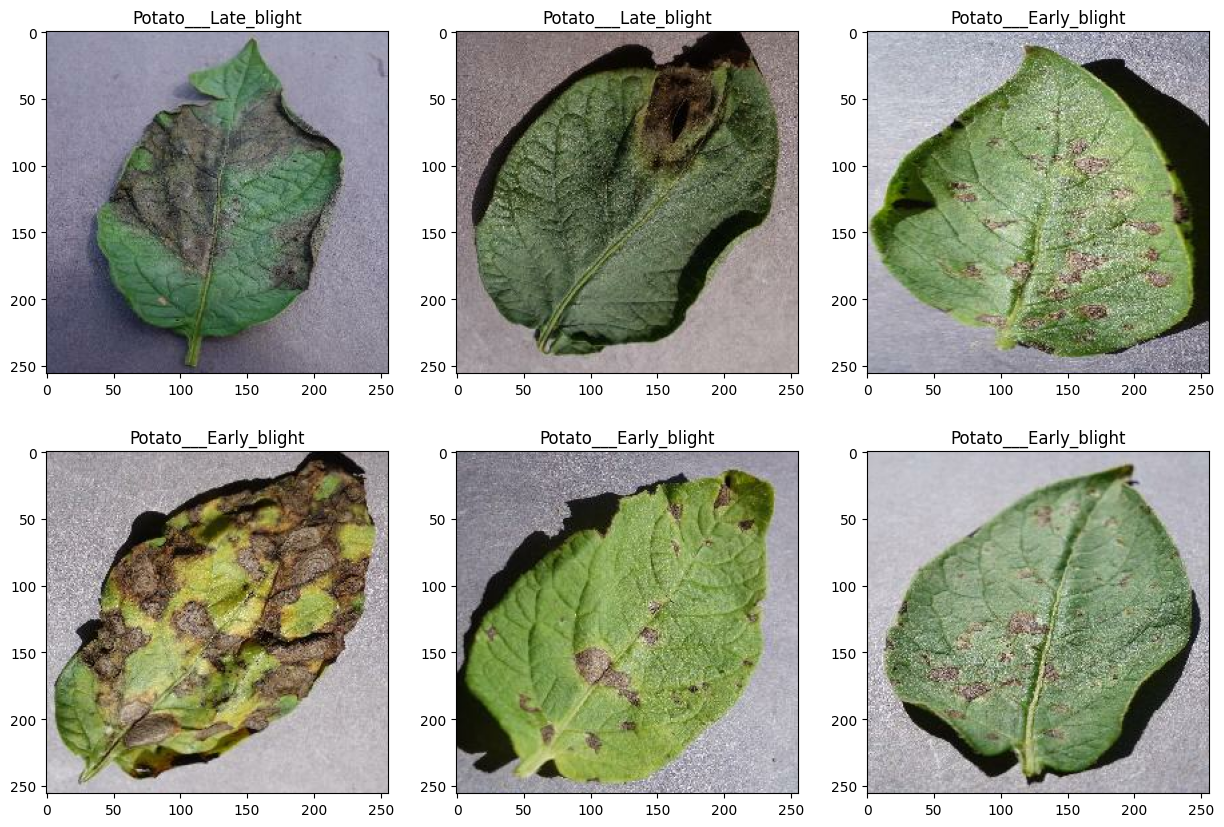

In [14]:
plt.figure(figsize=(15, 10))

for image_batch, label_batch in dataset.take(1):
  for i in range(6):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])


#Splitting the Dataset (Train and Test)

Splitting the dataset into training and testing if not available already (OPTIONAL)
* 70% for training
* 15% for validation
* 15% for testing

In [15]:
train_size = 0.7
len(dataset) * train_size


47.599999999999994

In [16]:
train_dataset = dataset.take(48)
len(train_dataset)


48

In [17]:
test_dataset = dataset.skip(48)  #skip first 48 batches of the images
len(test_dataset)


20

In [18]:
validation_size = 0.15
len(dataset) * validation_size

10.2

In [19]:
validation_dataset = test_dataset.skip(10)
len(validation_dataset)


10

In [20]:
#partitioning dataset
def get_dataset_partition_tf(dataset, train_split = 0.7, validation_split = 0.15, test_split = 0.15, shuffle = True, shuffle_size = 10000):
  dataset_size = len(dataset)

  if shuffle:
    dataset = dataset.shuffle(shuffle_size, seed = 18)
  
  train_size = int(train_split * dataset_size)
  validation_size = int(validation_split * dataset_size)

  train_dataset = dataset.take(train_size)
  validation_dataset = dataset.skip(train_size).take(validation_size)
  test_dataset = dataset.skip(train_size).skip(validation_size)
  
  return train_dataset, validation_dataset, test_dataset


In [21]:
train_dataset, validation_dataset, test_dataset = get_dataset_partition_tf(dataset)


In [22]:
len(train_dataset) 

47

In [23]:
len(validation_dataset) 

10

In [24]:
len(test_dataset)

11

In [25]:
#for, increasing system performance while training
#prefetch() - loads next batch of images into CPU when GPU is busy training images
#cache() - saves time while reading images
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
validation_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)


#Preprocessing of Images

Resizing and Rescaling

In [26]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])


Data Augmentation

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


#Model Building

In [28]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(n_classes, activation = 'softmax')
])
model.build(input_shape = input_shape)


In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)


In [31]:
history = model.fit(
    train_dataset,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = validation_dataset
)


Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 51s 967ms/step - accuracy: 0.5196 - loss: 0.8991 - val_accuracy: 0.5500 - val_loss: 0.8157
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6642 - loss: 0.7325 - val_accuracy: 0.6750 - val_loss: 0.7543
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8088 - loss: 0.4679 - val_accuracy: 0.8764 - val_loss: 0.3266
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8703 - loss: 0.3499 - val_accuracy: 0.8953 - val_loss: 0.2719
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8986 - loss: 0.2683 - val_accuracy: 0.8946 - val_loss: 0.2766
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9068 - loss: 0.2447 - val_accuracy: 0.8980 - val_loss: 0.2511
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9236 - loss: 0.2000 - val_accuracy: 0.9466 - val_loss: 0.1539
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9311 - loss: 0.1796 - val_accuracy: 0.8946 - val_lo

In [32]:
scores = model.evaluate(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.9784 - loss: 0.0581


In [33]:
scores

[0.05806657299399376, 0.9783783555030823]

In [34]:
history.params
history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

#Model Graphical Representation

In [35]:
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

loss = history.history['loss']
validation_loss = history.history['val_loss']


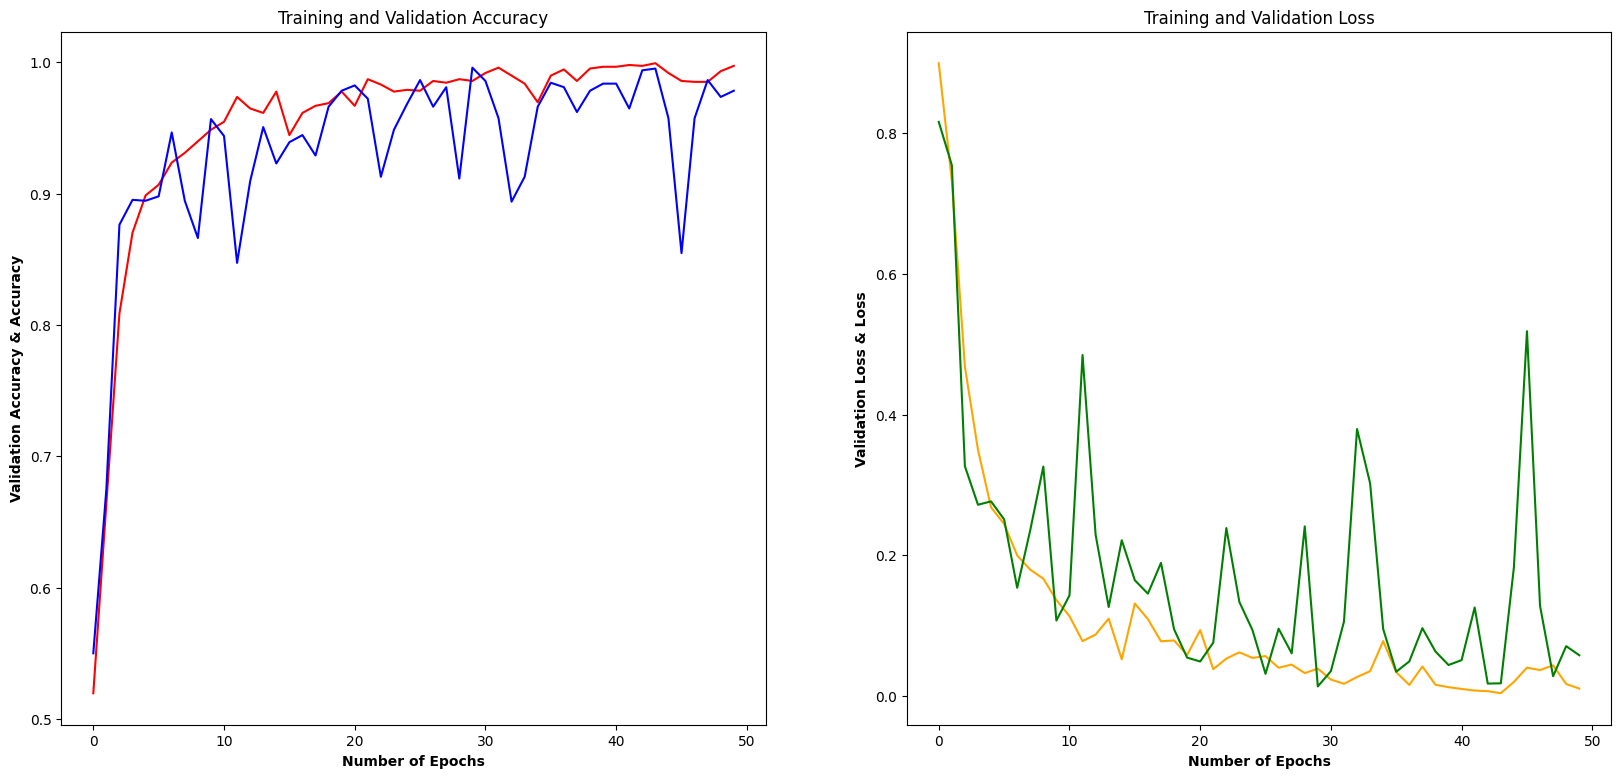

In [36]:
plt.figure(figsize = (20, 9), linewidth = 1.5)
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), accuracy, label = 'Training Accuracy', c = 'red')
plt.plot(range(EPOCHS), validation_accuracy, label = 'Validation Accuracy', c = 'blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Number of Epochs', fontweight='bold')
plt.ylabel('Validation Accuracy & Accuracy', fontweight='bold')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label = 'Training Loss', c = 'orange')
plt.plot(range(EPOCHS), validation_loss, label = 'Validation Loss', c = 'green')
plt.title('Training and Validation Loss')
plt.xlabel('Number of Epochs', fontweight='bold')
plt.ylabel('Validation Loss & Loss', fontweight='bold')

plt.show()


#Model Testing

actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
predicted label:  Potato___Early_blight


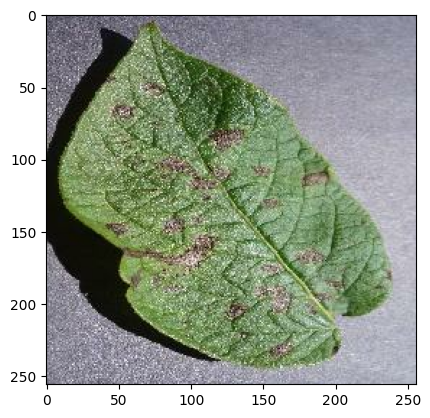

In [37]:
import numpy as np

for images_batch, labels_batch in test_dataset.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0]

  #print("first image to predict")
  plt.imshow(first_image)
  print("actual label: ", class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print("predicted label: ", class_names[np.argmax(batch_prediction[0])])


In [38]:
def predict(model, img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0)  #creating a batch

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100 * (np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


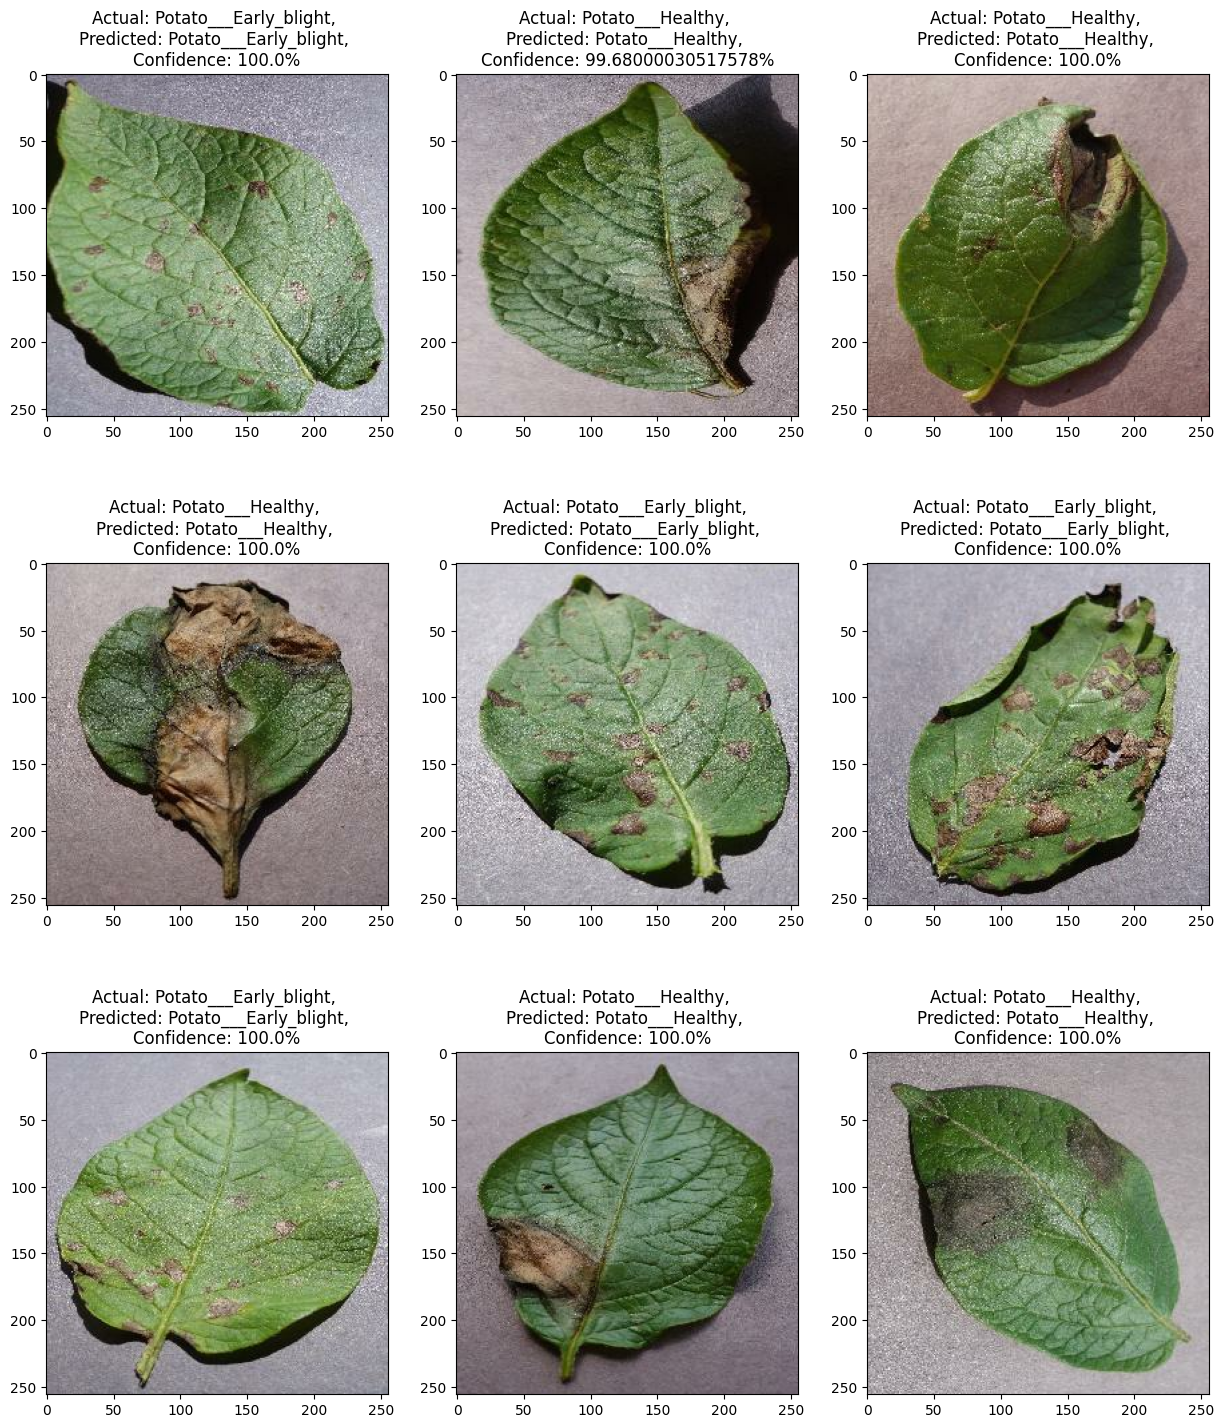

In [66]:
plt.figure(figsize = (15, 18))
for images, labels in test_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class}, \nPredicted: {predicted_class}, \nConfidence: {confidence}%")


In [67]:
def predict_single_image(image_path):
    # Read and preprocess the image
    img = tf.keras.preprocessing.image.load_img(
        image_path, 
        target_size=(IMAGE_SIZE, IMAGE_SIZE)
    )
    
    # Convert image to array
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # Expand dimensions to match model input shape
    img_array = tf.expand_dims(img_array, 0)
    
    # Make prediction
    predictions = model.predict(img_array)
    
    # Get predicted class and confidence
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    
    # Display image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence}%")
    plt.axis('off')
    plt.show()
    
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


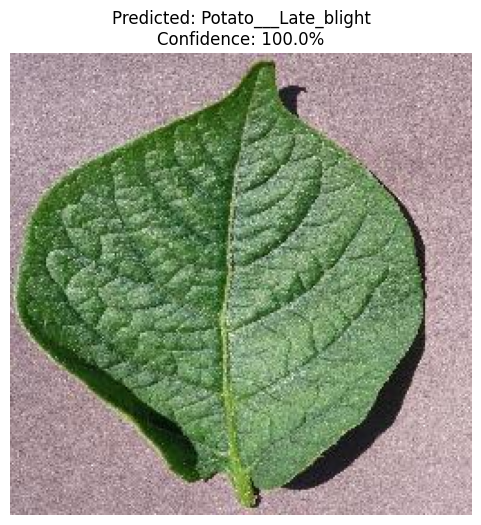

('Potato___Late_blight', np.float32(100.0))

In [72]:
predict_single_image(r"E:\potato_project\potato_project\Dataset\Potato___healthy\f5bd2732-197b-4d8e-bb50-a4966dc416f5___RS_HL 1840.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


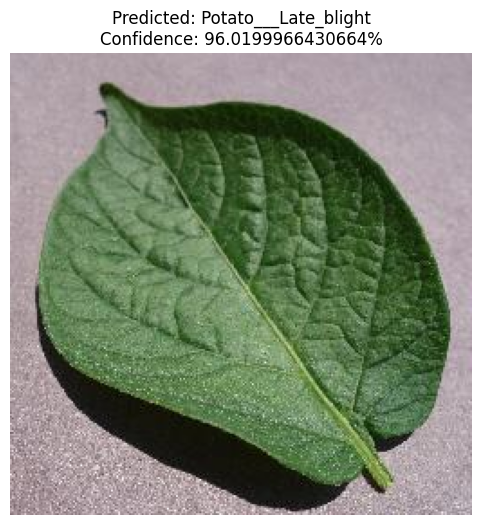

('Potato___Late_blight', np.float32(96.02))

In [73]:
predict_single_image(r"E:\potato_project\potato_project\Dataset\Potato___healthy\0b3e5032-8ae8-49ac-8157-a1cac3df01dd___RS_HL 1817.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


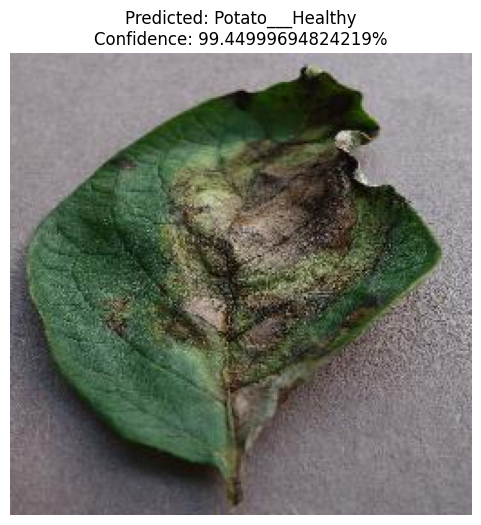

('Potato___Healthy', np.float32(99.45))

In [62]:
predict_single_image(r"E:\potato_project\potato_project\Dataset\Potato___Late_blight\0c2628d4-8d64-48a9-a157-19a9c902e304___RS_LB 4590.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


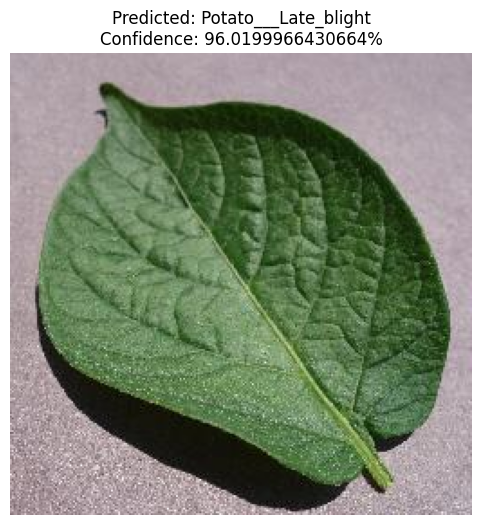

('Potato___Late_blight', np.float32(96.02))

In [55]:
predict_single_image(r"E:\potato_project\potato_project\Dataset\Potato___healthy\0b3e5032-8ae8-49ac-8157-a1cac3df01dd___RS_HL 1817.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


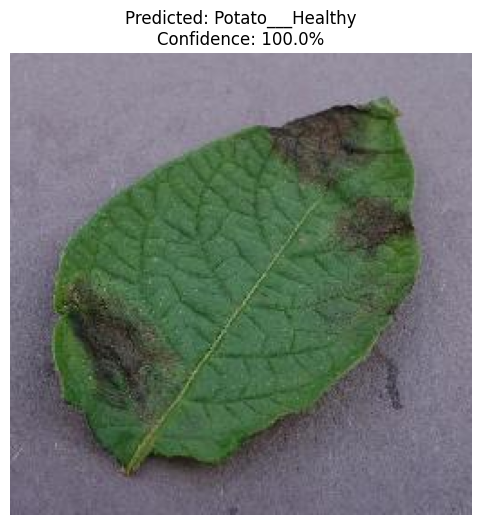

('Potato___Healthy', np.float32(100.0))

In [52]:
predict_single_image(r"E:\potato_project\potato_project\Dataset\Potato___Late_blight\4a911e79-f9c0-4ba1-aa80-567d653df61c___RS_LB 4038.JPG")

#Saving the best model

In [50]:
model.save(r"potato_model.keras")

changes

In [49]:
import json

class_names = [
    "Potato___Early_blight",
    "Potato___Healthy",
    "Potato___Late_blight"
]

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json created successfully")


class_names.json created successfully


In [75]:
train_ds.class_names


NameError: name 'train_ds' is not defined